# Phase 3 — EDA & Math Basics
**ML Foundations Capstone | Ames Housing Dataset**

**Khaled Waleed Althobaiti | خالد وليد الثبيتي**
Class 1/1 | صف 1/1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

## 0. Load Data

In [4]:
def clean_and_engineer(path):
    df = pd.read_csv(path)
    for col in ['MS SubClass', 'Mo Sold', 'Yr Sold']:
        df[col] = df[col].astype(str)
    df = df.drop_duplicates()
    none_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
                 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
                 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
                 'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    zero_cols = ['Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
                 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                 'Garage Cars', 'Garage Area', 'Garage Yr Blt']
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage']                            .transform(lambda x: x.fillna(x.median()))
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    df['SalePrice'] = df['SalePrice'].clip(upper=df['SalePrice'].quantile(0.99))
    Q1, Q3 = df['Gr Liv Area'].quantile([0.25, 0.75])
    df['Gr Liv Area'] = df['Gr Liv Area'].clip(upper=Q3 + 3*(Q3-Q1))
    df = df.drop(columns=['Order', 'PID'], errors='ignore')
    df['SalePrice_Log']    = np.log1p(df['SalePrice'])
    df['price_per_sqft']   = df['SalePrice'] / df['Gr Liv Area'].replace(0, np.nan)
    df['price_per_sqft']   = df['price_per_sqft'].fillna(df['price_per_sqft'].median())
    df['total_bathrooms']  = (df['Full Bath'] + 0.5*df['Half Bath'] +
                               df.get('Bsmt Full Bath', 0).fillna(0) +
                               0.5*df.get('Bsmt Half Bath', 0).fillna(0))
    df['qual_x_area']      = df['Overall Qual'] * df['Gr Liv Area']
    bins   = [0, 1940, 1960, 1980, 2000, 2025]
    labels = ['Historic', 'Older', 'Mid-Century', 'Modern', 'Recent']
    df['house_age_group']  = pd.cut(df['Year Built'], bins=bins, labels=labels)
    return df

df = clean_and_engineer('../data/raw/AmesHousing.csv')
print(f"Dataset ready: {df.shape}")
df[['SalePrice', 'Gr Liv Area', 'Overall Qual', 'price_per_sqft']].describe().round(1)

Dataset ready: (2930, 85)


,SalePrice,Gr Liv Area,Overall Qual,price_per_sqft
count,2930.0,2930.0,2930.0,2930.0
mean,179956.7,1497.4,6.1,121.1
std,76074.6,493.0,1.4,31.5
min,12789.0,334.0,1.0,15.4
25%,129500.0,1126.0,5.0,99.9
50%,160000.0,1442.0,6.0,120.2
75%,213500.0,1742.8,7.0,139.6
max,456666.4,3593.0,10.0,276.3


## EDA

### Chart 1 — Distributions of Three Key Features

SalePrice is right-skewed — most homes are in the $100k–$250k range but there are some expensive ones that pull the tail out. Living area looks similar. Overall quality clusters around 5–7 so truly excellent homes are rare. Taking the log of SalePrice makes the distribution much more symmetric.

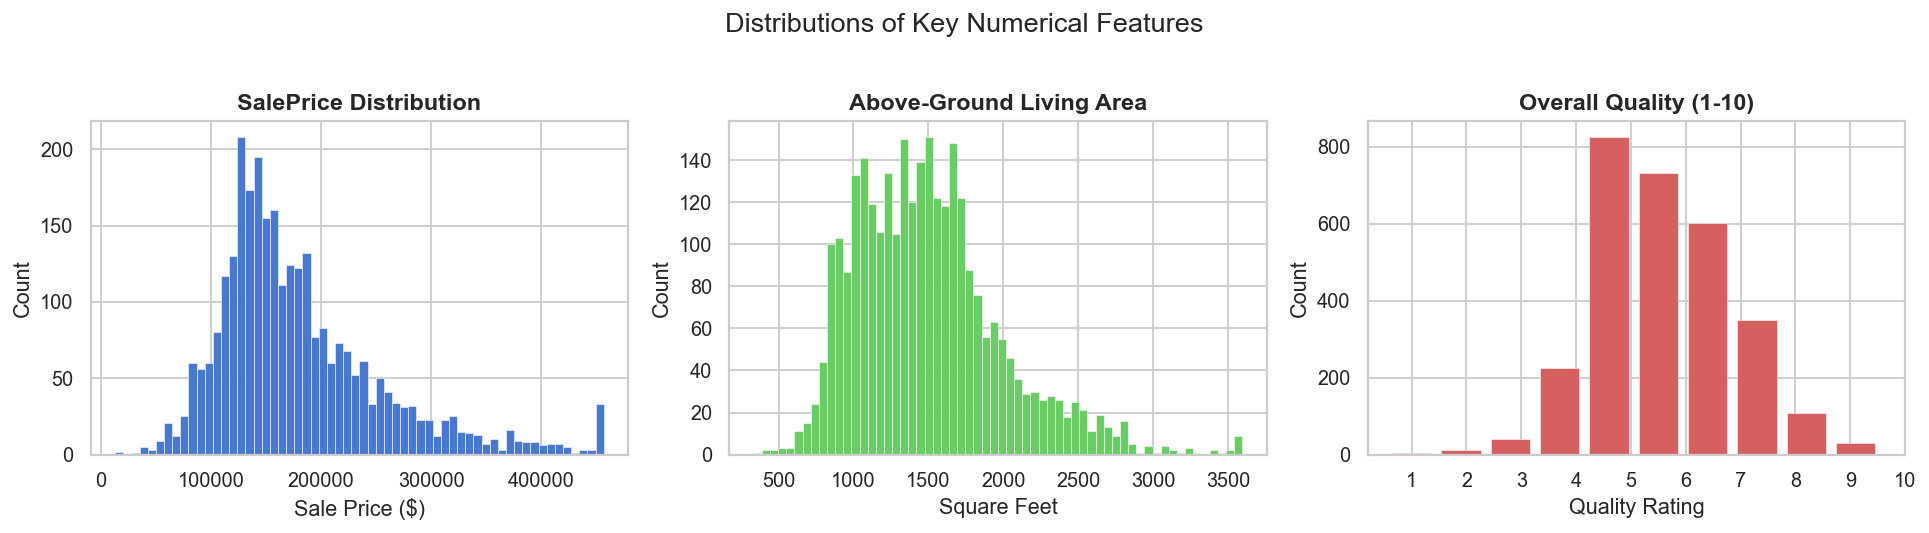

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['SalePrice'], bins=60, color='#4878CF', edgecolor='white', linewidth=0.3)
axes[0].set_title('SalePrice Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(df['Gr Liv Area'], bins=60, color='#6ACC65', edgecolor='white', linewidth=0.3)
axes[1].set_title('Above-Ground Living Area', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Square Feet')
axes[1].set_ylabel('Count')

axes[2].hist(df['Overall Qual'], bins=10, color='#D65F5F', edgecolor='white', linewidth=0.3,
             align='left', rwidth=0.8)
axes[2].set_title('Overall Quality (1-10)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Quality Rating')
axes[2].set_ylabel('Count')
axes[2].set_xticks(range(1, 11))

plt.suptitle('Distributions of Key Numerical Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('../data/cleaned/chart1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2 — SalePrice by Quality and Building Type

Sale price goes up clearly with quality. The median price for a quality-9 home is roughly 4× a quality-5 home. Among building types, single-family detached homes (1Fam) have the highest prices overall, while townhouse end units are tighter and lower.

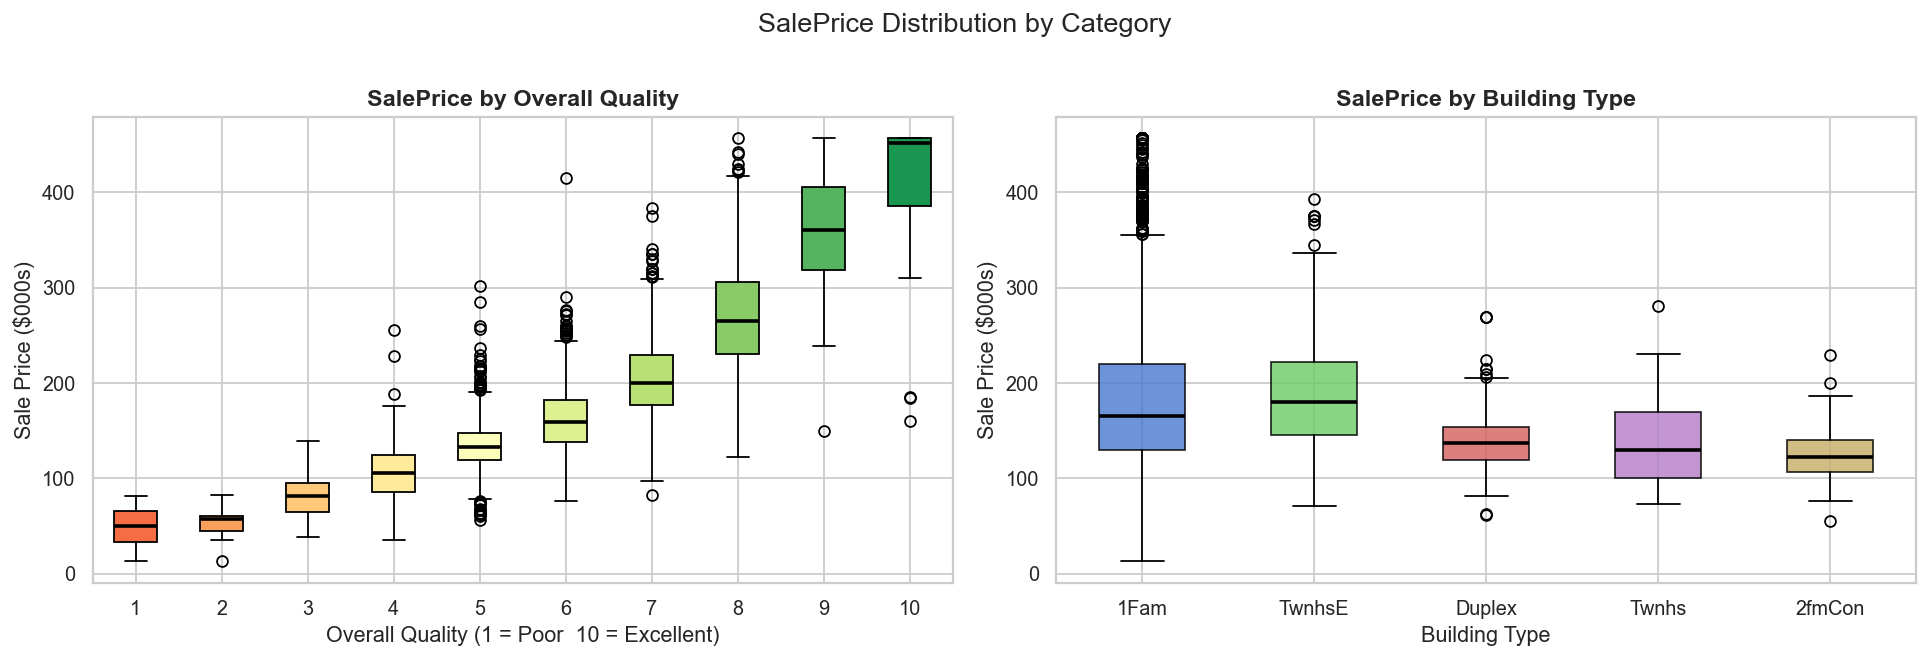

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

qual_order = sorted(df['Overall Qual'].unique())
groups_qual = [df[df['Overall Qual'] == q]['SalePrice'] / 1000 for q in qual_order]
bp1 = axes[0].boxplot(groups_qual, labels=qual_order, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(qual_order)))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title('SalePrice by Overall Quality', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Overall Quality (1 = Poor  10 = Excellent)')
axes[0].set_ylabel('Sale Price ($000s)')

bldg_order = df['Bldg Type'].value_counts().index.tolist()
groups_bldg = [df[df['Bldg Type'] == b]['SalePrice'] / 1000 for b in bldg_order]
bp2 = axes[1].boxplot(groups_bldg, labels=bldg_order, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
palette = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']
for patch, color in zip(bp2['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('SalePrice by Building Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Building Type')
axes[1].set_ylabel('Sale Price ($000s)')

plt.suptitle('SalePrice Distribution by Category', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../data/cleaned/chart2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3 — Correlation Heatmap

Overall quality has the strongest correlation with sale price (r ≈ 0.80), followed by living area. The engineered `qual_x_area` feature ended up with the highest correlation of all, which shows that creating interaction features was worth doing.

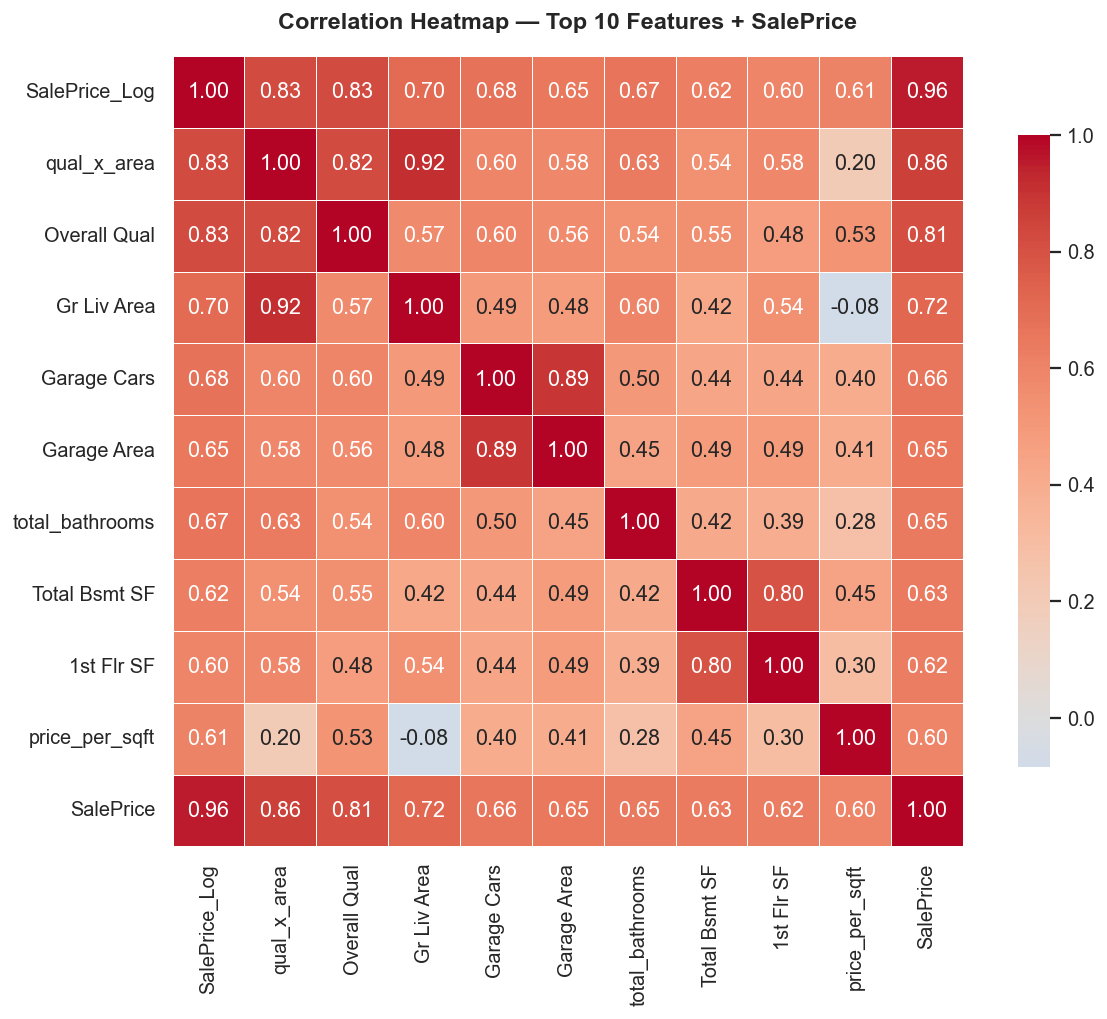

Top 10 correlations with SalePrice:
SalePrice_Log      0.955
qual_x_area        0.863
Overall Qual       0.812
Gr Liv Area        0.719
Garage Cars        0.662
Garage Area        0.652
total_bathrooms    0.646
Total Bsmt SF      0.634
1st Flr SF         0.623
price_per_sqft     0.600


In [5]:
num_df = df.select_dtypes(include='number').dropna(axis=1)
corr_with_price = num_df.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
top10 = corr_with_price.head(10).index.tolist()

corr_top10 = num_df[top10 + ['SalePrice']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_top10, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Top 10 Features + SalePrice',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/cleaned/chart3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 correlations with SalePrice:")
print(corr_with_price.head(10).round(3).to_string())

### Chart 4 — Living Area vs Sale Price

There is a clear positive trend between size and price. The colour coding by quality makes the pattern even clearer — almost all the expensive homes (top right) are dark green (quality 8–10), while cheaper homes at the same size are red or orange.

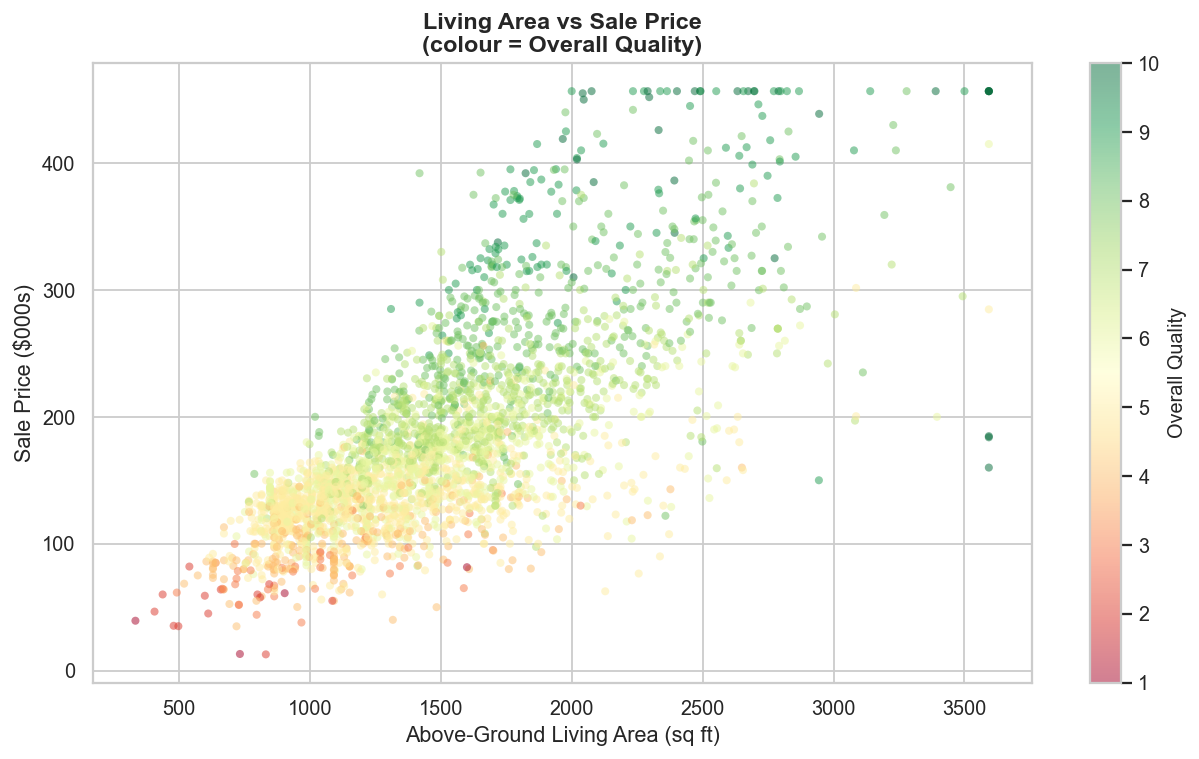

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['Gr Liv Area'], df['SalePrice'] / 1000,
                     c=df['Overall Qual'], cmap='RdYlGn',
                     alpha=0.5, s=20, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Overall Quality', fontsize=11)

ax.set_xlabel('Above-Ground Living Area (sq ft)', fontsize=12)
ax.set_ylabel('Sale Price ($000s)', fontsize=12)
ax.set_title('Living Area vs Sale Price\n(colour = Overall Quality)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/cleaned/chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5 — Mean Sale Price by Neighbourhood

Location makes a huge difference. The most expensive neighbourhood (NoRidge) averages over $330k while the cheapest (MeadowV) averages under $96k — a 3.5× gap. This tells me neighbourhood should be carefully encoded in any predictive model.

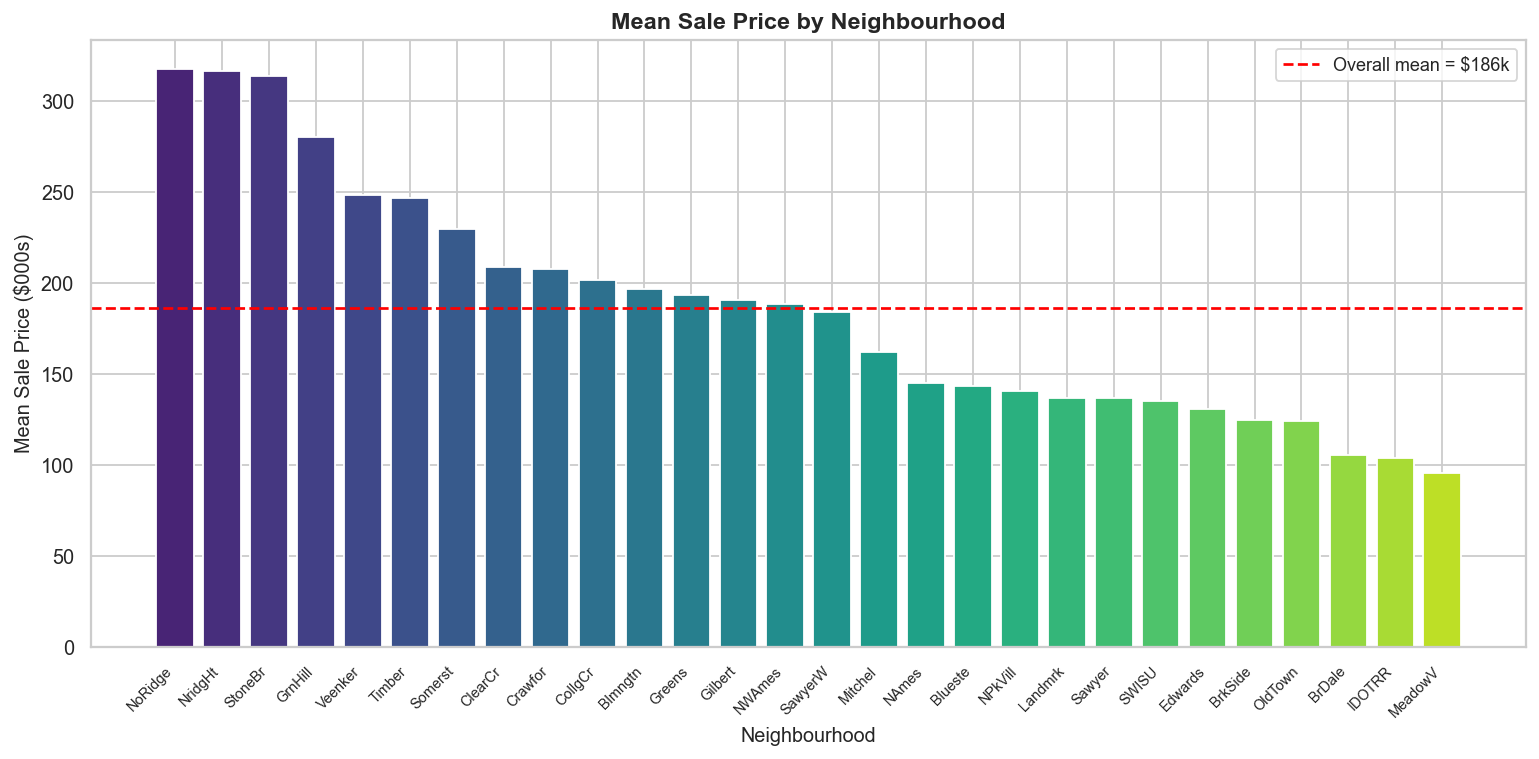

Most expensive: NoRidge at $317.7k
Least expensive: MeadowV at $95.8k


In [7]:
nbhd_price = (df.groupby('Neighborhood')['SalePrice']
               .mean()
               .sort_values(ascending=False)
               / 1000)

fig, ax = plt.subplots(figsize=(12, 6))
colors_nbhd = plt.cm.viridis(np.linspace(0.1, 0.9, len(nbhd_price)))
ax.bar(nbhd_price.index, nbhd_price.values, color=colors_nbhd, edgecolor='white')
ax.set_xlabel('Neighbourhood', fontsize=11)
ax.set_ylabel('Mean Sale Price ($000s)', fontsize=11)
ax.set_title('Mean Sale Price by Neighbourhood', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.axhline(nbhd_price.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Overall mean = ${nbhd_price.mean():.0f}k')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/cleaned/chart5_neighbourhood.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most expensive: {nbhd_price.idxmax()} at ${nbhd_price.max():.1f}k")
print(f"Least expensive: {nbhd_price.idxmin()} at ${nbhd_price.min():.1f}k")

---
## Math Basics

### Task 1 — Mean and Standard Deviation (calculated manually with NumPy)

In [2]:
prices = df['SalePrice'].values.astype(float)

mean_manual = np.sum(prices) / len(prices)
variance    = np.sum((prices - mean_manual) ** 2) / len(prices)
std_manual  = np.sqrt(variance)

print(f"Manual mean:  ${mean_manual:,.2f}")
print(f"Manual std:   ${std_manual:,.2f}")
print()
print(f"np.mean():    ${np.mean(prices):,.2f}  " if abs(np.mean(prices) - mean_manual) < 1 else " mismatch")
print(f"np.std():     ${np.std(prices):,.2f}  " if abs(np.std(prices) - std_manual) < 1 else " mismatch")

NameError: name 'df' is not defined

### Task 2 — Manual Z-score vs StandardScaler

In [9]:
X = df['Gr Liv Area'].values.astype(float)

mu  = np.sum(X) / len(X)
sig = np.sqrt(np.sum((X - mu)**2) / len(X))
z_manual = (X - mu) / sig

scaler = StandardScaler()
z_sklearn = scaler.fit_transform(X.reshape(-1, 1)).flatten()

print("Manual z-score vs StandardScaler (first 5 rows):")
for m, s in list(zip(z_manual[:5], z_sklearn[:5])):
    match = '' if abs(m - s) < 1e-6 else ''
    print(f"  manual={m:.6f}   sklearn={s:.6f}  {match}")

print(f"\nMax absolute difference: {np.max(np.abs(z_manual - z_sklearn)):.2e}")

Manual z-score vs StandardScaler (first 5 rows):
  manual=0.321685   sklearn=0.321685  
  manual=-1.220193   sklearn=-1.220193  
  manual=-0.341728   sklearn=-0.341728  
  manual=1.242755   sklearn=1.242755  
  manual=0.266908   sklearn=0.266908  

Max absolute difference: 0.00e+00


### Task 3 — Cosine Similarity: Cheapest vs Most Expensive Home

In [10]:
feature_cols = ['Gr Liv Area', 'Overall Qual', 'Year Built', 'Total Bsmt SF',
                'Garage Area', 'Lot Area', '1st Flr SF', 'Full Bath',
                'TotRms AbvGrd', 'Fireplaces']

sub = df[feature_cols].fillna(0)

idx_high = df['SalePrice'].idxmax()
idx_low  = df['SalePrice'].idxmin()

vec_high = sub.loc[idx_high].values.astype(float)
vec_low  = sub.loc[idx_low].values.astype(float)

dot_product = np.dot(vec_high, vec_low)
cos_sim = dot_product / (np.linalg.norm(vec_high) * np.linalg.norm(vec_low))

print(f"Highest-value home — SalePrice: ${df.loc[idx_high, 'SalePrice']:,.0f}")
print(f"Lowest-value home  — SalePrice: ${df.loc[idx_low, 'SalePrice']:,.0f}")
print(f"\nFeature vectors (selected cols):")
print(f"  High: {vec_high}")
print(f"  Low:  {vec_low}")
print(f"\nCosine similarity: {cos_sim:.4f}")
print("(1.0 = identical direction, 0 = perpendicular, -1 = opposite)")

Highest-value home — SalePrice: $456,666
Lowest-value home  — SalePrice: $12,789

Feature vectors (selected cols):
  High: [3.2790e+03 8.0000e+00 2.0030e+03 1.6500e+03 8.4100e+02 5.3504e+04
 1.6900e+03 3.0000e+00 1.2000e+01 1.0000e+00]
  Low:  [8.320e+02 2.000e+00 1.923e+03 6.780e+02 7.800e+02 9.656e+03 8.320e+02
 1.000e+00 5.000e+00 1.000e+00]

Cosine similarity: 0.9833
(1.0 = identical direction, 0 = perpendicular, -1 = opposite)


### Task 4 — Probability: How often do high-quality homes sell above median?

In [11]:
median_price = df['SalePrice'].median()
high_quality = df[df['Overall Qual'] >= 8]

p_above_median_given_hq = (high_quality['SalePrice'] > median_price).mean()
p_above_median_overall  = (df['SalePrice'] > median_price).mean()

print(f"Median sale price (all homes):                ${median_price:,.0f}")
print(f"P(price > median | any home):                 {p_above_median_overall:.3f}  ({p_above_median_overall*100:.1f}%)")
print(f"P(price > median | Overall Qual ≥ 8):         {p_above_median_given_hq:.3f}  ({p_above_median_given_hq*100:.1f}%)")
print()
print(f"High-quality homes are {p_above_median_given_hq/p_above_median_overall:.1f}× more likely to sell above median.")

Median sale price (all homes):                $160,000
P(price > median | any home):                 0.499  (49.9%)
P(price > median | Overall Qual ≥ 8):         0.986  (98.6%)

High-quality homes are 2.0× more likely to sell above median.
